<a href="https://colab.research.google.com/github/Kartikmankar786/Books/blob/main/Time_series_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mean: -0.04077096517208498
Variance: 0.8624344486801115


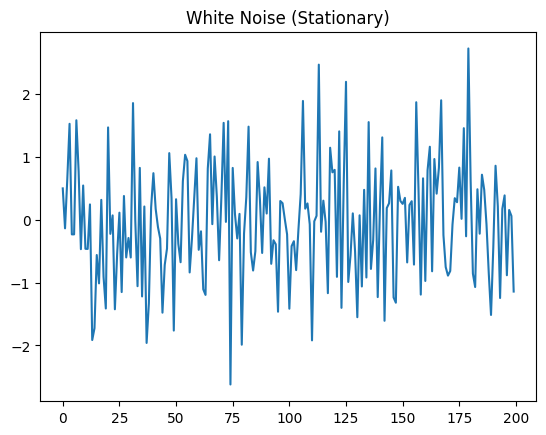

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate white noise
data = np.random.normal(loc=0, scale=1, size=200)

print("Mean:", np.mean(data))
print("Variance:", np.var(data))

plt.plot(data)
plt.title("White Noise (Stationary)")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(data)

print("\nADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"   {key}: {value}")

# Decision
if result[1] < 0.05:
    print("\nSeries is Stationary (Reject H0)")
else:
    print("\nSeries is Non-Stationary (Fail to Reject H0)")


ADF Statistic: -14.74419994660189
p-value: 2.543125112212854e-27
Critical Values:
   1%: -3.4636447617687436
   5%: -2.8761761179270766
   10%: -2.57457158581854

Series is Stationary (Reject H0)


**Seasonal Decompose**



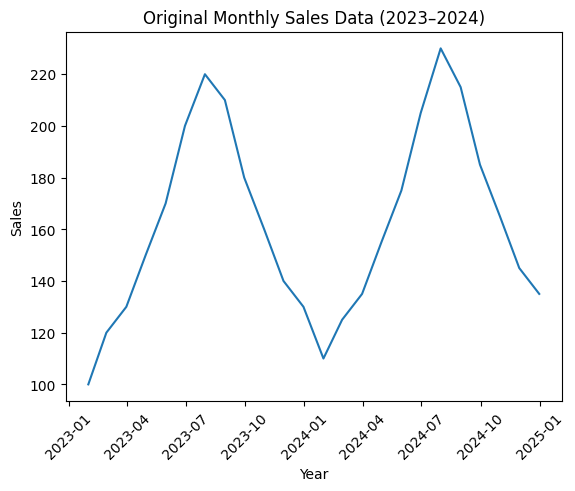

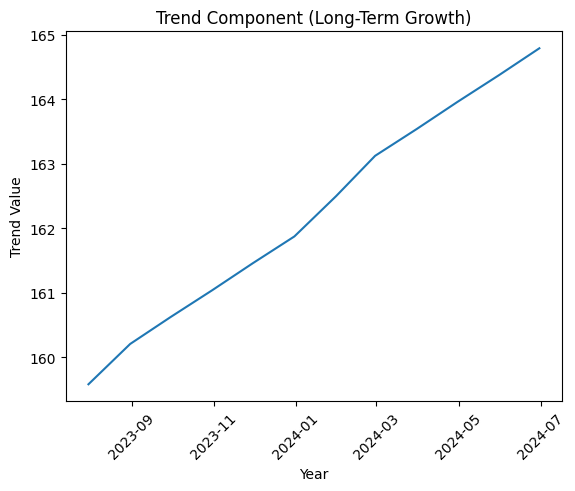

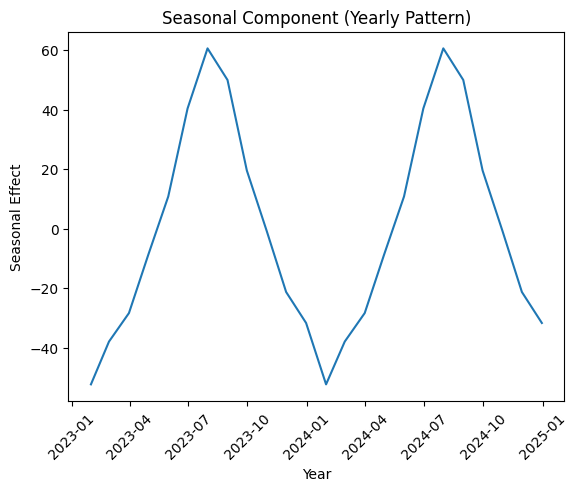

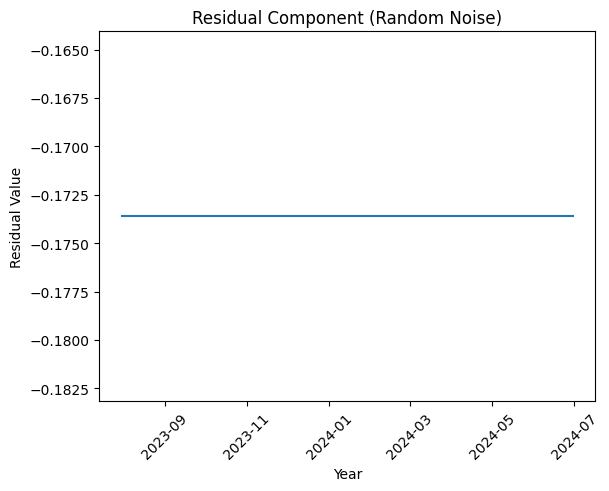

In [ ]:
# Improved Seasonal Decomposition Plots (Separate & Properly Labeled)

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 24 months data (2 years)
data = [
    100,120,130,150,170,200,220,210,180,160,140,130,
    110,125,135,155,175,205,230,215,185,165,145,135
]

index = pd.date_range(start='2023-01-01', periods=24, freq='ME')
ts = pd.Series(data, index=index)

result = seasonal_decompose(ts, model='additive', period=12)

# 1️⃣ Original Data
plt.figure()
plt.plot(ts)
plt.title("Original Monthly Sales Data (2023–2024)")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# 2️⃣ Trend Component
plt.figure()
plt.plot(result.trend)
plt.title("Trend Component (Long-Term Growth)")
plt.xlabel("Year")
plt.ylabel("Trend Value")
plt.xticks(rotation=45)
plt.show()

# 3️⃣ Seasonal Component
plt.figure()
plt.plot(result.seasonal)
plt.title("Seasonal Component (Yearly Pattern)")
plt.xlabel("Year")
plt.ylabel("Seasonal Effect")
plt.xticks(rotation=45)
plt.show()

# 4️⃣ Residual Component
plt.figure()
plt.plot(result.resid)
plt.title("Residual Component (Random Noise)")
plt.xlabel("Year")
plt.ylabel("Residual Value")
plt.xticks(rotation=45)
plt.show()
